In [1]:
import numpy as np
import pyEXP
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.pyplot import cm
import cmasher as cmr
import pandas as pd
from astropy.table import Table, vstack
import scipy

from functools import partial
from matplotlib import animation
from matplotlib.animation import FuncAnimation
%matplotlib inline

import sys
import importlib
sys.path.append('../code/')
import helper
import run_mssa

In [2]:
tbl = Table.read('../data/kiyan-mssa_prep_table_with_time.fits')
tbl.sort(["timestep", "jphi_cen", "tphi_cen"])

In [3]:
tbl['time_since_int_m1'][(tbl['pitch_phase_flag_m1'] > 0) | ~(tbl['time_since_int_m1'] > -np.inf)] = -1

In [4]:
plt.hist(tbl['timestep'][tbl['time_since_int_m1'] ==-1], bins=300)
plt.show()

/var/folders/f1/wqzqbly11d9__jf5mjckhwvm0000gq/T/ipykernel_12339/698649648.py:2: UserWarning: FigureCanvasPdf is non-interactive, and thus cannot be shown
  plt.show()



In [50]:
tbl['timestep', 'jphi_cen', 'tphi_cen', 'time_since_int_m1', 'pitch_phase_flag_m1'][(tbl['timestep'] < 120) & (tbl['timestep'] >= 80) & 
(tbl['jphi_cen'] < 1400)]

timestep,jphi_cen,tphi_cen,time_since_int_m1,pitch_phase_flag_m1
float64,float64,float64,float64,float64
80.0,1000.0,0.19634954084936207,0.3532374015137223,0.0
80.0,1000.0,0.5890486225480862,0.3158333830837787,0.0
80.0,1000.0,0.9817477042468103,0.4432293895835588,0.0
80.0,1000.0,1.3744467859455345,0.39423262083350197,0.0
80.0,1000.0,1.7671458676442586,0.3712350504916534,0.0
80.0,1000.0,2.1598449493429825,0.41979719316107406,0.0
80.0,1000.0,2.552544031041707,0.3699839457022665,0.0
80.0,1000.0,2.945243112740431,0.3628933236721961,0.0
80.0,1000.0,3.3379421944391554,-1.0,1.0


In [5]:
jphi_c = np.arange(1000, 3000+1, 100)
tphi_c_ = np.linspace(0, 2*np.pi, 16+1)
rad = [0.5*(jphi_c[1] - jphi_c[0]), 0.5*(tphi_c_[1] - tphi_c_[0])]
tphi_c = tphi_c_[:-1] + rad[1]
centers = np.array(np.meshgrid(jphi_c, tphi_c)).T.reshape(-1,2)

cfs_m0_amp    = ['m0_amp_{}_{}pi16'.format(int(cf[0]), int(16*cf[1]/np.pi)) for cf in centers]
cfs_m1_amp    = ['m1_amp_{}_{}pi16'.format(int(cf[0]), int(16*cf[1]/np.pi)) for cf in centers]
cfs_m2_amp    = ['m2_amp_{}_{}pi16'.format(int(cf[0]), int(16*cf[1]/np.pi)) for cf in centers]
cfs_m1_pitch  = ['m1_pitch_{}_{}pi16'.format(int(cf[0]), int(16*cf[1]/np.pi)) for cf in centers]
cfs_m2_pitch  = ['m2_pitch_{}_{}pi16'.format(int(cf[0]), int(16*cf[1]/np.pi)) for cf in centers]
cfs_m1_phase  = ['m1_phase_{}_{}pi16'.format(int(cf[0]), int(16*cf[1]/np.pi)) for cf in centers]
cfs_m2_phase  = ['m2_phase_{}_{}pi16'.format(int(cf[0]), int(16*cf[1]/np.pi)) for cf in centers]
cfs_m1_int_time = ['m1_int_time_{}_{}pi16'.format(int(cf[0]), int(16*cf[1]/np.pi)) for cf in centers]
cfs_m2_int_time = ['m2_int_time_{}_{}pi16'.format(int(cf[0]), int(16*cf[1]/np.pi)) for cf in centers]

colnames = ['timestep']+cfs_m0_amp+cfs_m1_amp+cfs_m2_amp+cfs_m1_pitch+cfs_m2_pitch+cfs_m1_phase+cfs_m2_phase+cfs_m1_int_time+cfs_m2_int_time

t = Table(names=colnames)

for time in np.unique(tbl['timestep']):
    subset = tbl[tbl['timestep'] == time]
    channels = np.concatenate([np.array(subset['m0_amp']), np.array(subset['m1_amp']), np.array(subset['m2_amp']),
                               np.array(subset['pitch_ang_m1']), np.array(subset['pitch_ang_m2']), 
                               np.array(subset['phase_ang_m1']), np.array(subset['phase_ang_m2']),
                               np.array(time*0.01 - subset['time_since_int_m1']),
                               np.array(time*0.01 - subset['time_since_int_m2'])])
    #amps = np.concatenate((subset['m1_amp'], subset['m2_amp']))
    t.add_row(np.append([time], channels))

np.savetxt('../data/kiyan-test_for_mssa.dat', t)

## Save Interaction Times

In [224]:
def save_int_time_coefs(directory, channel_file, n_channels, j_bins=20, start_timestep=40, end_timestep=None):
    file = np.loadtxt(directory+channel_file)
    n_times = file.shape[0]
    if end_timestep==None:
        times = np.reshape(file[start_timestep:,0], (n_times-start_timestep,1))
    else:
        times = np.reshape(file[start_timestep:end_timestep,0], (end_timestep-start_timestep,1))
    
    m1_int_time_coefs = file[start_timestep:end_timestep,7*n_channels+1:8*n_channels+1]# - 16*5]
    m2_int_time_coefs = file[start_timestep:end_timestep,8*n_channels+1:9*n_channels+1]# - 16*5]
    
    m1_int_time = np.concatenate([times, m1_int_time_coefs], axis=1)
    m2_int_time = np.concatenate([times, m2_int_time_coefs], axis=1)
    
    fname_prefix = directory+'mSSA_channels_Kiyan_test_t40-300/'
    np.savetxt(fname_prefix + 'm1_int_time_bins_j{}_t16.dat'.format(j_bins), m1_int_time)
    np.savetxt(fname_prefix + 'm2_int_time_bins_j{}_t16.dat'.format(j_bins), m2_int_time)

In [225]:
save_int_time_coefs(directory='../data/', channel_file='kiyan-test_for_mssa.dat', 
           n_channels=336, j_bins=20, start_timestep=40, end_timestep=120)

### Loading in Files

In [6]:
directory = '../data/mSSA_channels_Kiyan_test_t40-300/'

fname_m1_int_time = directory+'m1_int_time_bins_j20_t16.dat'

coefs_m1_int_time0 = pyEXP.coefs.Coefs.factory(fname_m1_int_time)

coefs_m1_int_time = coefs_m1_int_time0.deepcopy()

---- Coefs::factory: error opening as HDF5, trying EXP native and ascii table
---- Coefs::factory: read ascii and created TableData


In [7]:
# A list with three keys.  Keys are integer arrays (or lists).  
# The first column of the data table has the key [0], etc.
#keylst = [[i] for i in range(len(coefs.getAllCoefs()))]

n_channels = int(len(coefs_m1_int_time.getAllCoefs()))
times = coefs_m1_int_time.Times()

keylst_m1_int_time = [[i] for i in range(n_channels)]

config = {"snails_m1_int_time": (coefs_m1_int_time, keylst_m1_int_time, [])}

# Window size is half the time series (a good default choice if it's practical)
window = int(len(times)/2)

# Only compute the first 30 PCs
npc = 30

flags = """
verbose: true
"""

mssa = pyEXP.mssa.expMSSA(config, window, npc, flags)

---- Eigen is using 4 threads


In [8]:
fig_dir = '../figures/kiyan_test_figures/m1_int_time/'

In [9]:
ev = mssa.eigenvalues()

shape U = 13440 x 41
shape Y = 41 x 13440


In [10]:
coefs_m1_int_time.zerodata()
mssa.reconstruct([*range(30)])

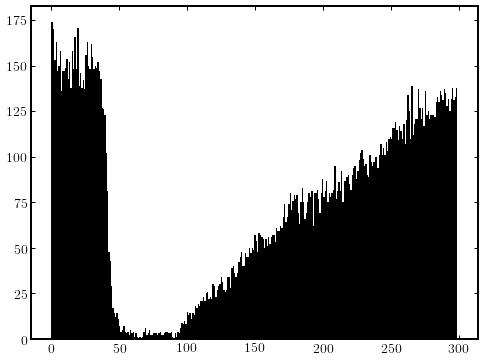

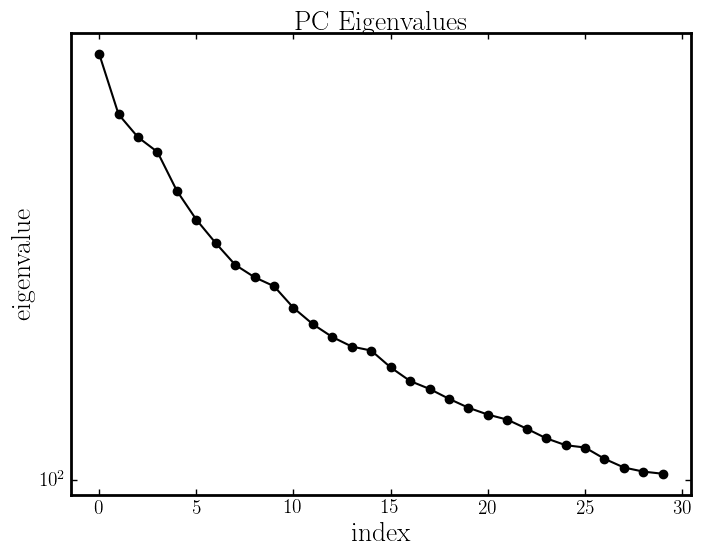

In [11]:
%matplotlib inline
fig, ax1 = plt.subplots(1, 1, figsize=(8, 6))

ax1.semilogy(ev[:30], '-o')

ax1.set_xlabel('index', fontsize=20)
ax1.set_ylabel('eigenvalue', fontsize=20)
    
ax1.set_title('PC Eigenvalues', fontsize=20)
#plt.savefig(fig_dir+'eigenvalues.pdf')
#plt.savefig(fig_dir+'eigenvalues.png')
plt.show()

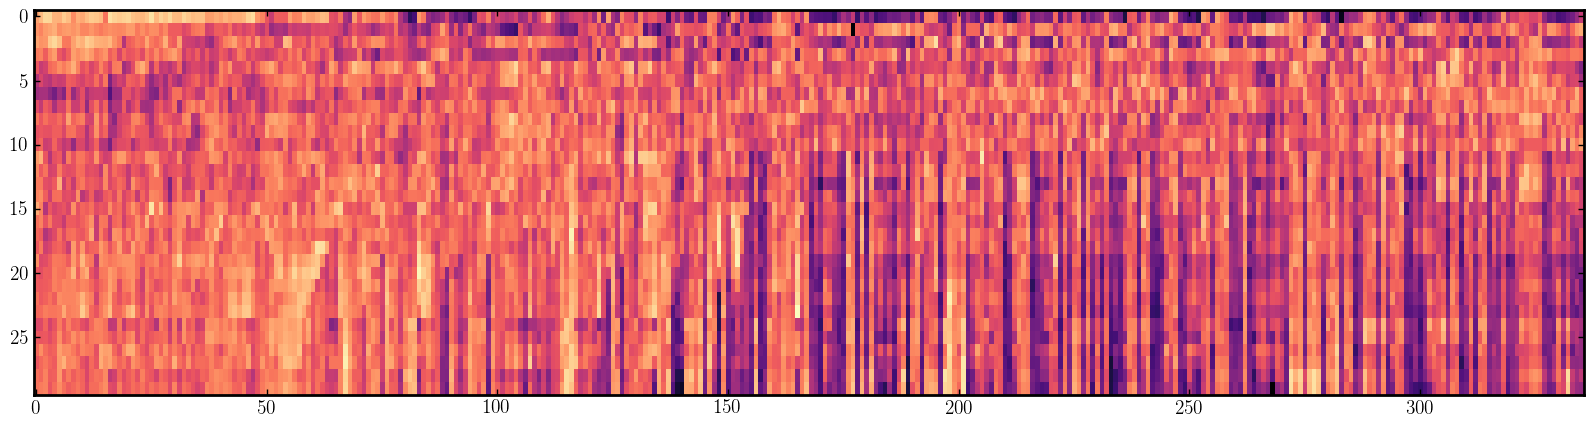

In [11]:
t1, t2 = mssa.contrib()
plt.figure(figsize=(20, 5))
plt.imshow(t2, aspect='auto', norm=mpl.colors.LogNorm())

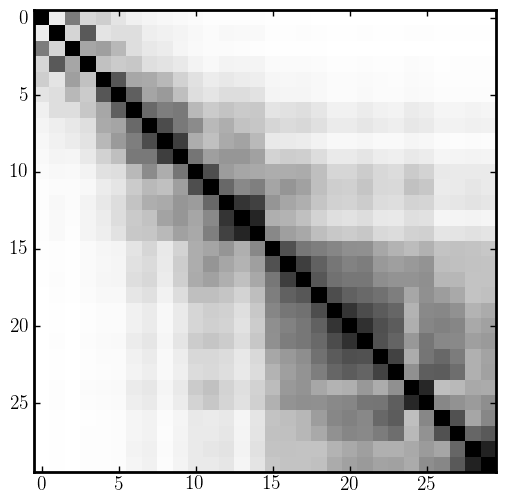

In [12]:
fig, ax = plt.subplots(1, 1, figsize=(6,6), sharey=True)

ax.imshow(mssa.wCorrAll()[:30, :30], cmap='gray_r')
#plt.savefig(fig_dir+'wCorr30.pdf')
#plt.savefig(fig_dir+'wCorr30.png') 
plt.show()

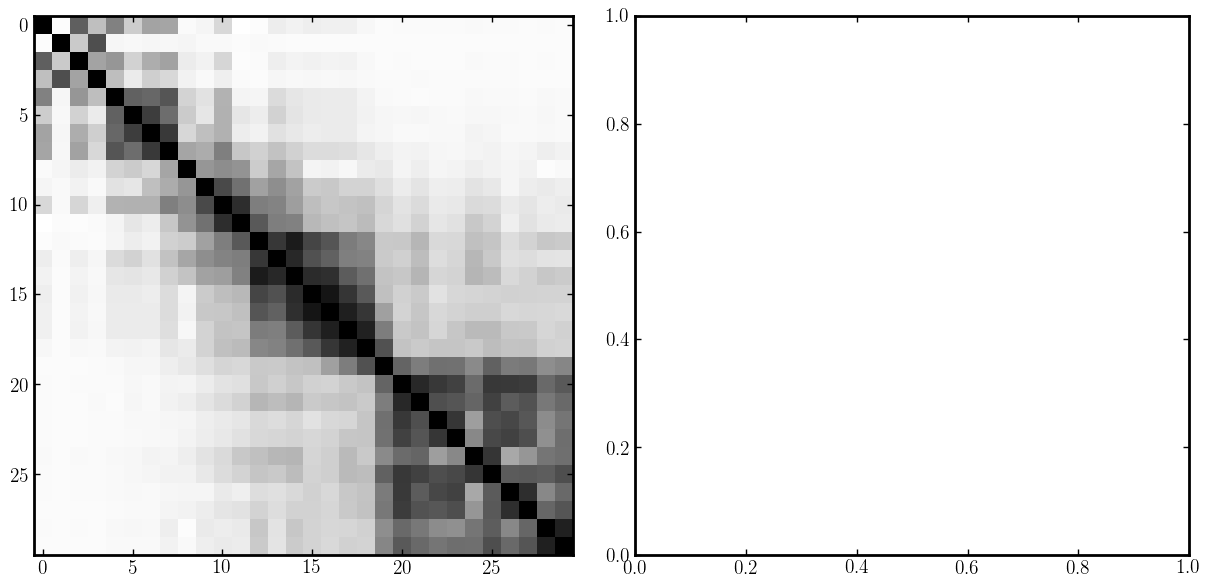

In [13]:
# wCorr for amplitude:
fig, [ax1, ax2] = plt.subplots(1, 2, figsize=(15,7))
ax1.imshow(mssa.wCorrKey([0]), cmap='gray_r')
#ax2.imshow(mssa.wCorrKey([1]), cmap='gray_r')
plt.show()

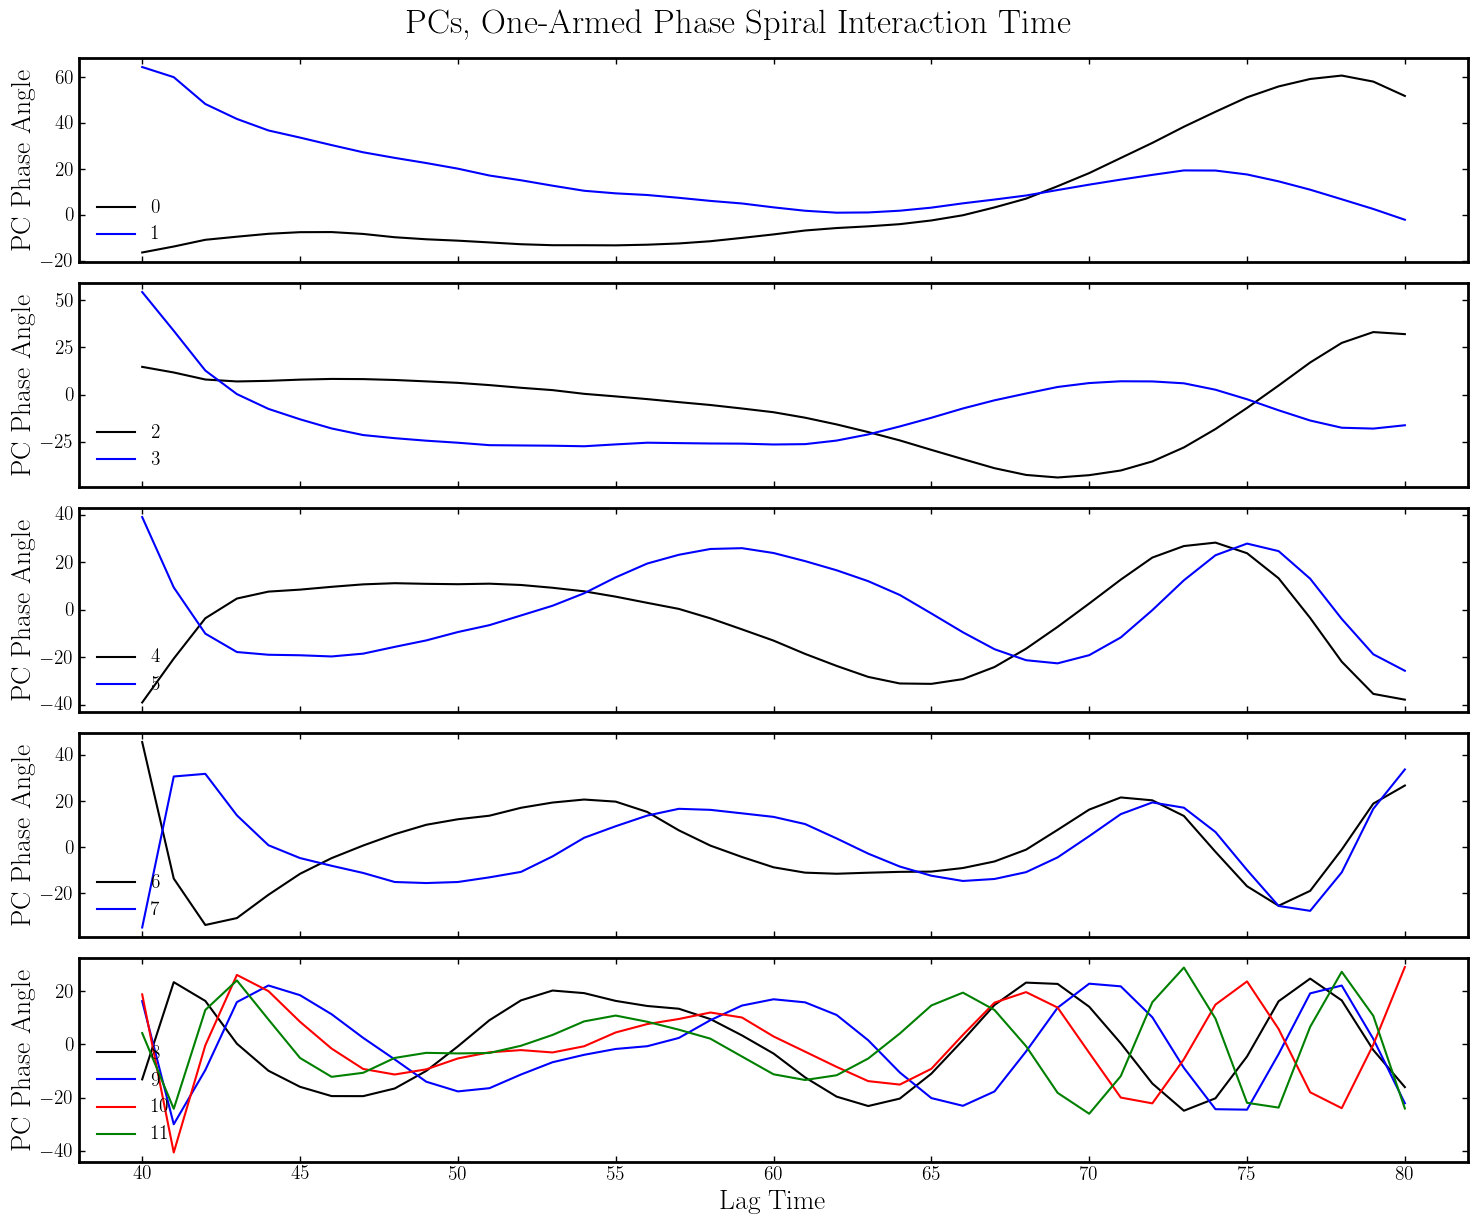

In [14]:
%matplotlib inline
pc = mssa.getPC()

nt = pc.shape[0]
lag_times = times[:nt]

n_plots = 5
fig, axs = plt.subplots(n_plots, 1, figsize=(15, 2.5*n_plots), sharex=True)

for i in range(0,2):
    axs[0].plot(lag_times, pc[:,i], label=str(i)) 

plt.suptitle('PCs, One-Armed Phase Spiral Interaction Time', fontsize=25)

for i in range(2,4):
    axs[1].plot(lag_times, pc[:,i], label=str(i))    
    
for i in range(4,6):
    axs[2].plot(lag_times, pc[:,i], label=str(i))    
    
for i in range(6,8):
    axs[3].plot(lag_times, pc[:,i], label=str(i))
    
for i in range(8,12):
    axs[4].plot(lag_times, pc[:,i], label=str(i))  
    
# for i in range(18,22):
#     axs[5].plot(lag_times, pc[:,i], label=str(i))  

# for i in range(16,19):
#     axs[6].plot(lag_times, pc[:,i], label=str(i))  

for i in range(n_plots):
    axs[i].set_ylabel('PC Phase Angle', fontsize=20)
    axs[i].legend(fontsize=14, loc='lower left')
axs[-1].set_xlabel('Lag Time', fontsize=20)
        
fig.tight_layout()
#plt.savefig(fig_dir+'PCs.png')
#plt.savefig(fig_dir+'PCs.pdf') 
plt.show()

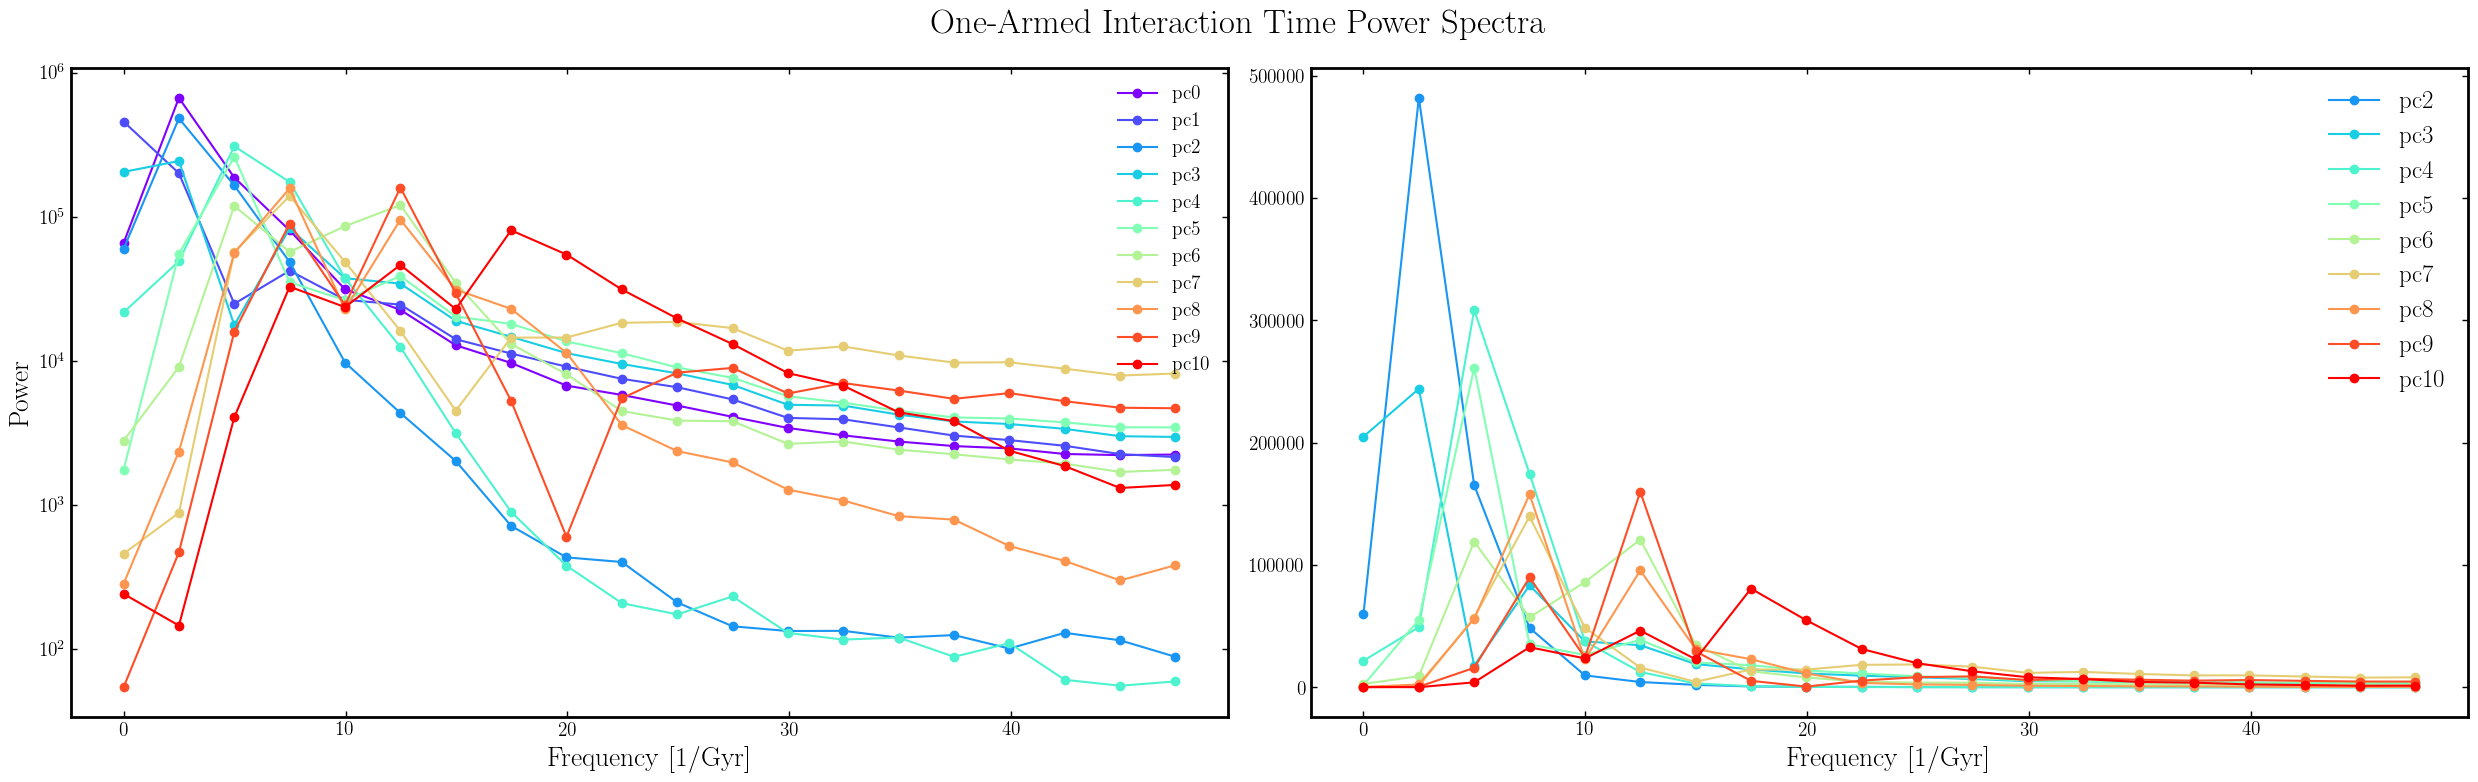

In [237]:
freq, power = mssa.pcDFT()
fig, [ax1, ax2] = plt.subplots(1, 2, figsize=(25, 8))

color = iter(cm.rainbow(np.linspace(0, 1, 11)))
    
for i in range(0, 11,1):
    c = next(color)
    ax1.plot(freq[:20] * (1/0.009778)/(2*np.pi), power[:20,i], '-o', c=c, label='pc'+str(i))

    if i>=2:
        ax2.plot(freq[:20] * (1/0.009778)/(2*np.pi), power[:20,i], '-o', c=c, label='pc'+str(i))

ax1.set_xlabel('Frequency [1/Gyr]', fontsize=20)
ax2.set_xlabel('Frequency [1/Gyr]', fontsize=20)
ax1.legend() ; ax2.legend(fontsize=18)
ax1.set_ylabel('Power', fontsize=20)
ax1.set_yscale('log')

plt.suptitle('One-Armed Interaction Time Power Spectra', fontsize=25)
fig.tight_layout()
#plt.savefig(fig_dir+'power_spectrum.pdf')
plt.show()

### Face-on Plots

In [36]:
mpl.matplotlib_fname()

'/Users/Tavangar/.matplotlib/matplotlibrc'

In [17]:
data_fname = directory+'m1_int_time_bins_j20_t16.dat'

MSSA = run_mssa.MSSAOperations(data_fname, 'one-armed rewind_time', fig_dir)

pc_lists = [[0],[0,1,2,3], list(range(4,8)), list(range(0,8)), list(range(4,15)), list(range(0,15)), list(range(15,30))]
MSSA.make_pc_movies(pc_lists, norm_function=mpl.colors.Normalize, 
                    sim_name='test', jphi_min=1000, jbins=21,
                    cmap=cmr.prinsenvlag_r, vmin=0.3, vmax=0.5)


# importlib.reload(sys.modules['helper'])
# from helper import *

# tbl_int_time = np.loadtxt(directory+'m1_int_time_bins_j20_t16.dat')

# f = fig_dir+'face-on_plots/data_m1_int_time_light_bkg.mp4'

# tdict = {'int_time': tbl_int_time}

# mpl.style.use('/Users/Tavangar/.matplotlib/matplotlibrc')
# MakeAnim = MakeAnimations(mssa=mssa, sim_name='test', channel_name='one-armed interaction time', times=times, jphi_min=1000, jbins=21)
# MakeAnim.make_data_mov(f, tbl_int_time, norm_function=mpl.colors.Normalize, cmap=cmr.prinsenvlag_r, vmin=0.3, vmax=0.5)

figure directory exists - adding to it
Creating movie for [0]
shape U = 13440 x 41
shape Y = 41 x 13440


---- Coefs::factory: error opening as HDF5, trying EXP native and ascii table
---- Coefs::factory: read ascii and created TableData


Creating movie for [0, 1, 2, 3]
Creating movie for [4, 5, 6, 7]
Creating movie for [0, 1, 2, 3, 4, 5, 6, 7]
Creating movie for [4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]
Creating movie for [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]
Creating movie for [15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29]


In [12]:
importlib.reload(sys.modules['helper'])
from helper import *

tbl_int_time = np.loadtxt(directory+'m1_int_time_bins_j20_t16.dat')

f = fig_dir+'face-on_plots/data_m1_int_time_light_bkg.mp4'

tdict = {'int_time': tbl_int_time}

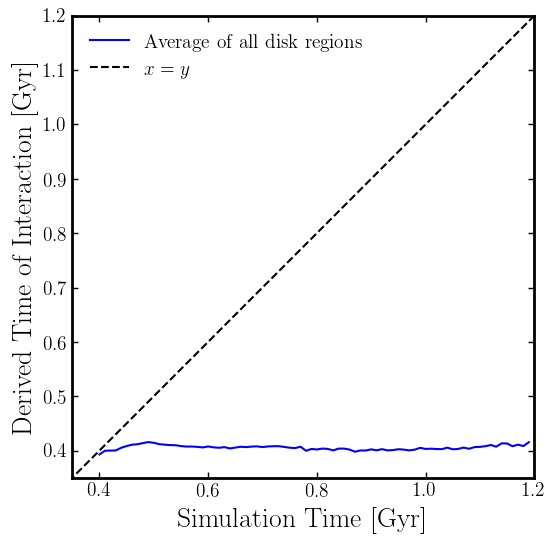

In [48]:
plt.figure(figsize=(6,6))
plt.plot(0.01*tbl_int_time[:,0], np.median(tbl_int_time[:,1:], axis=1), label='Average of all disk regions', c='b')
# plt.plot(0.01*tbl_int_time[:,0], np.mean(tbl_int_time[:,1:250], axis=1), label='Inner average')
plt.plot([0.3,1.2], [0.3,1.2], label=r'$x=y$', ls='--', c='k')
plt.legend(loc='upper left')
plt.xlabel('Simulation Time [Gyr]', fontsize=20)
plt.ylabel('Derived Time of Interaction [Gyr]', fontsize=20)
plt.xlim(0.35,1.2) ; plt.ylim(0.35,1.2)
ax=plt.gca()
ax.set_aspect('equal')
plt.savefig(fig_dir+'average_int_time.pdf')
plt.show()

In [48]:
np.where(tbl_int_time[:,1:] > tbl_int_time[:,0])

ValueError: operands could not be broadcast together with shapes (80,336) (80,) 

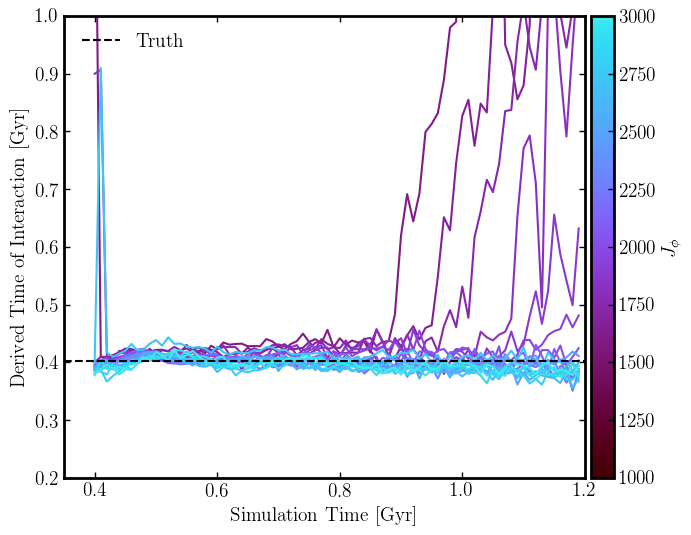

In [27]:
fig, ax = plt.subplots(1,1,figsize=(8,6))

# Define the range of J_phi values
jphi_vals = 1000 + 100 * np.arange(21)

# Create color normalization and mappable for colorbar
norm = Normalize(vmin=jphi_vals.min(), vmax=jphi_vals.max())
cmap = cmr.gem
sm = ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])  # Required for colorbar

# Set color cycle
colors = cmap(np.linspace(0.3, 1, 21))
ax.set_prop_cycle(color=colors)

# Plot each line
for i in range(21):
    yvals = np.median(np.reshape(tbl_int_time[:,1:], (80, 16, 21), 'F'), axis=1)[:,i]
    ax.plot(0.01*np.arange(40,120), yvals)

# Plot truth line
ax.axhline(0.403, ls='--', c='k', label='Truth')

# Add legend
ax.legend(loc='upper left')

# Labels and limits
ax.set_xlabel('Simulation Time [Gyr]', fontsize=14)
ax.set_ylabel('Derived Time of Interaction [Gyr]', fontsize=14)
ax.set_xlim(0.35,1.2)
ax.set_ylim(0.2,1)

# Add colorbar
cbar = fig.colorbar(sm, ax=ax, pad=0.01)
cbar.set_label(r'$J_\phi$')

plt.show()

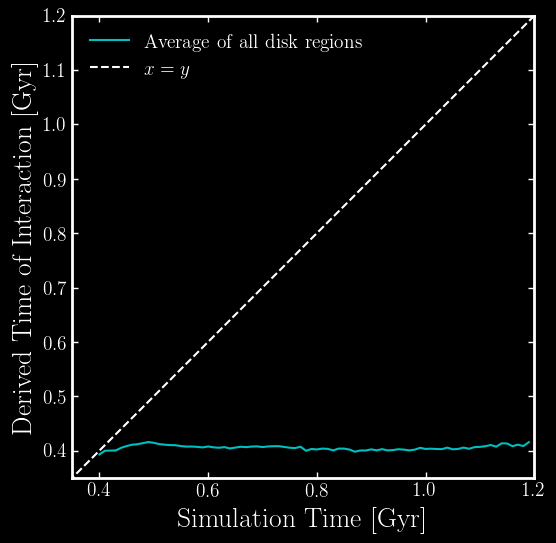

In [52]:
mpl.style.use('dark_background')
plt.figure(figsize=(6,6))
plt.plot(0.01*tbl_int_time[:,0], np.median(tbl_int_time[:,1:], axis=1), label='Average of all disk regions', c='c')
# plt.plot(0.01*tbl_int_time[:,0], np.mean(tbl_int_time[:,1:250], axis=1), label='Inner average')
plt.plot([0.3,1.2], [0.3,1.2], label=r'$x=y$', ls='--', c='w')
plt.legend(loc='upper left')
plt.xlabel('Simulation Time [Gyr]', fontsize=20)
plt.ylabel('Derived Time of Interaction [Gyr]', fontsize=20)
plt.xlim(0.35,1.2) ; plt.ylim(0.35,1.2)
ax=plt.gca()
ax.set_aspect('equal')
plt.savefig(fig_dir+'average_int_time_dark_bkg.pdf')
plt.show()

Updating for: (c)_0
Updating for: (s)_0
Updating for: (p)_0
Updating for: (
)_0
Updating for: (�)_0
Updating for: (m)_0
Updating for: ()_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: ( )_0
336
Making movies for just Amplitude or Pitch Angle
Updating for: (�)_0
Updating for: (�)_0
Updating for: (o)_0
Updating for: (�)_0
Updating for: ()_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: (~)_0
Updating for: (�)_0
Updating for: (Q)_0
Updating for: ()_0
Updating for: ()_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: (�)_0
Updating for: (~)_0
Updating for: (w)_0
Updating for: ()_0
Updating for: ()_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: (�)_0
Updating for: ()_0
Updating for: (�)_0
Updating for: (m)_0
Updating for: ()_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: (�)_0
Updating for: ()_0
Updating for: (!)_0
Updating for: (X)_0
Updating for: ()_0
Updating

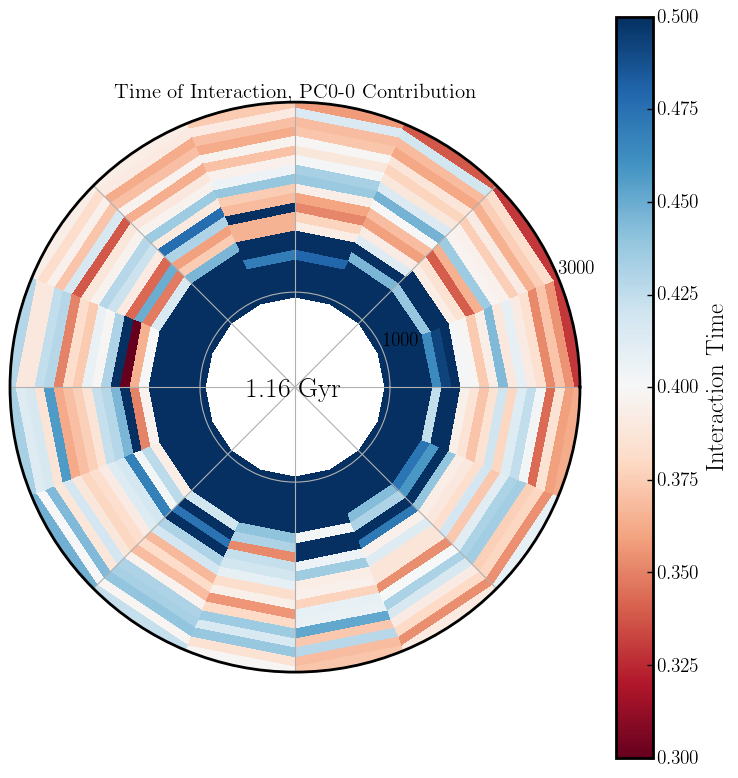

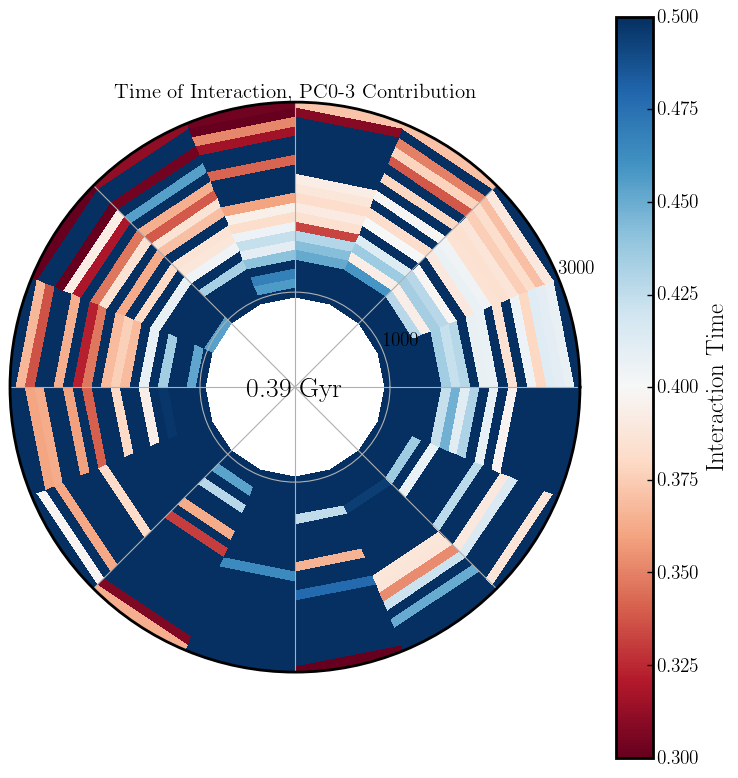

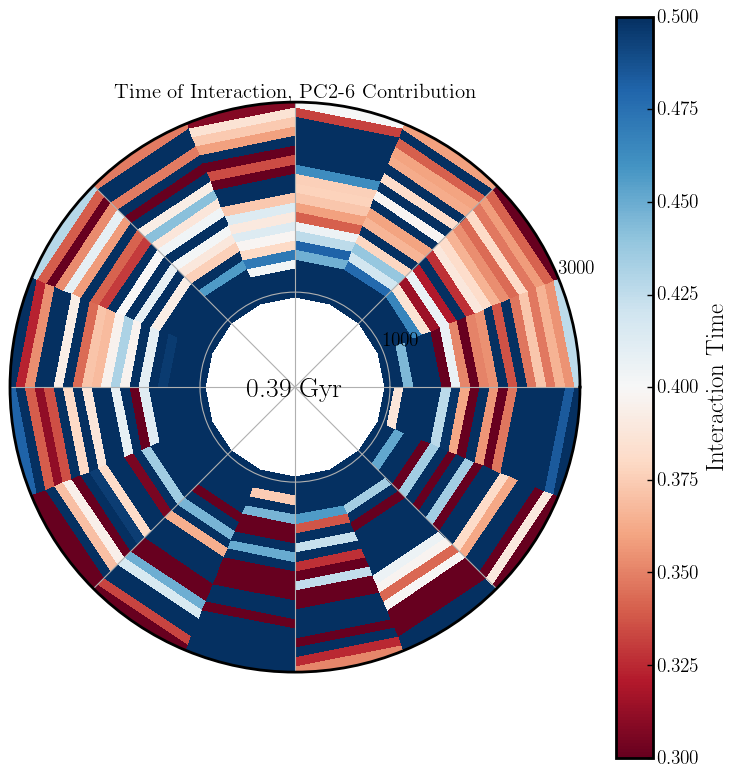

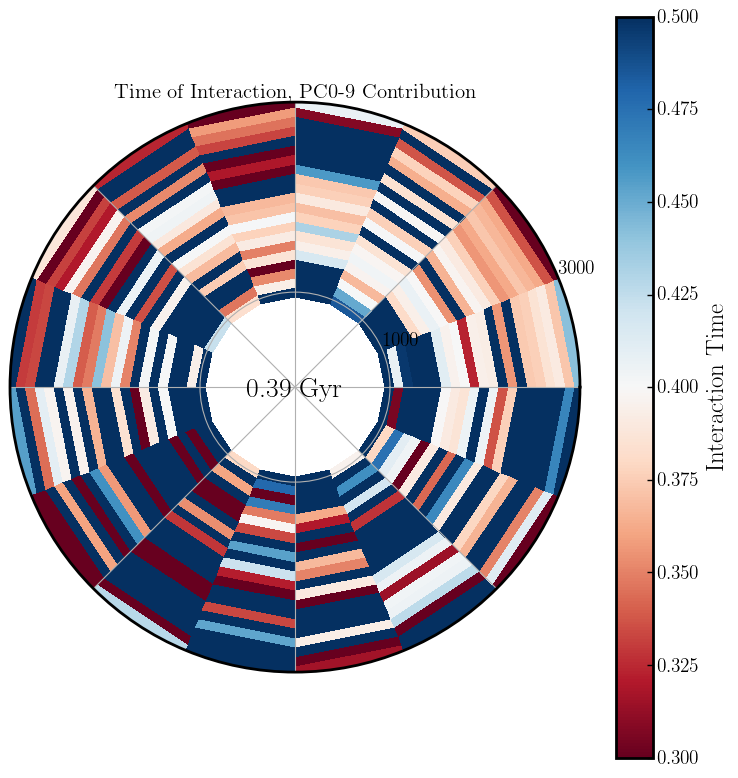

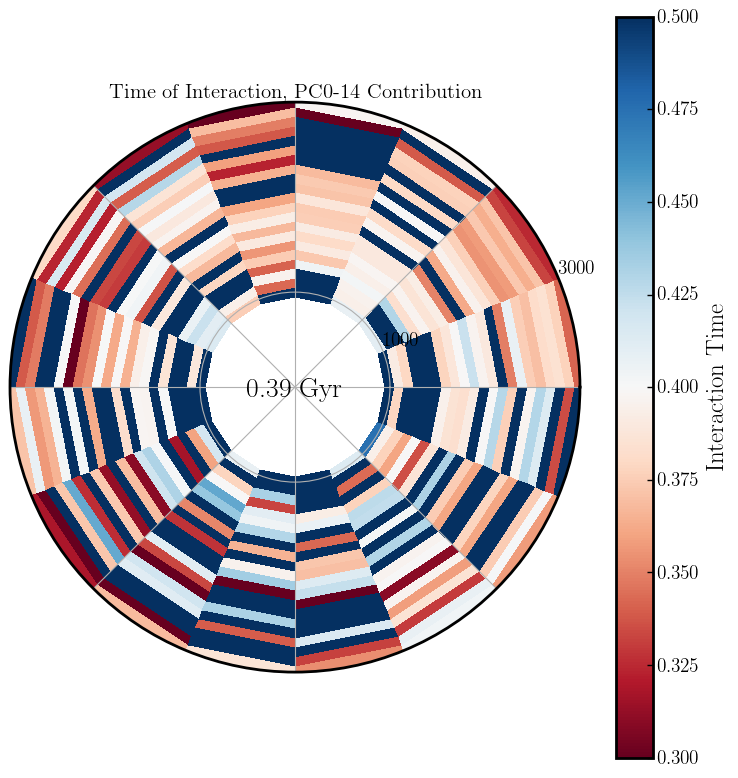

In [279]:
importlib.reload(sys.modules['helper'])
from helper import *

f = fig_dir+'face-on_plots/m1_int_time_pc0.mp4'
MakeAnim0 = MakeAnimations(mssa, 'int_time', times, n_channels, [0], jbins=20)
MakeAnim0.make_recon_mov_disk_plot(f)

f = fig_dir+'face-on_plots/m1_int_time_pc0-3.mp4'
MakeAnim1 = MakeAnimations(mssa, 'int_time', times, n_channels, list(range(0,4)), jbins=20)
MakeAnim1.make_recon_mov_disk_plot(f)

f = fig_dir+'face-on_plots/m1_int_time_pc4-9.mp4'
MakeAnim2 = MakeAnimations(mssa, 'int_time', times, n_channels, list(range(2,7)), jbins=20)
MakeAnim2.make_recon_mov_disk_plot(f)

f = fig_dir+'face-on_plots/m1_int_time_pc0-9.mp4'
MakeAnim3 = MakeAnimations(mssa, 'int_time', times, n_channels, list(range(0,10)), jbins=20)
MakeAnim3.make_recon_mov_disk_plot(f)

f = fig_dir+'face-on_plots/m1_int_time_pc0-14.mp4'
MakeAnim4 = MakeAnimations(mssa, 'int_time', times, n_channels, list(range(0,15)), jbins=20)
MakeAnim4.make_recon_mov_disk_plot(f)

## Rewinding this

In [31]:
# To get colorbar
jphi_c = np.linspace(1000, 3000, 20+1)
tphi_c_ = np.linspace(0, 2*np.pi, 16+1)
rad = [0.5*(jphi_c[1] - jphi_c[0]), 0.5*(tphi_c_[1] - tphi_c_[0])]
tphi_c = tphi_c_[:-1] + rad[1]
J, T = np.meshgrid(jphi_c, tphi_c)

In [32]:
freqs = np.load('../data/test_frequency_array_j25.npy')[:21]

In [33]:
# Take Reconstructions
mssa.reconstruct(list(range(0,3)))
get_recon = mssa.getReconstructed()

recon_amp_ = get_recon[list(get_recon.keys())[0]].getAllCoefs()
recon_amp = recon_amp_ - np.mean(recon_amp_, axis=0)

#recon_pitch_ = get_recon[list(get_recon.keys())[1]].getAllCoefs()
#recon_pitch = recon_pitch_ - np.mean(recon_pitch_, axis=0)

# what is omega_phi at each radius, in rad/Gyr?
omega_phi = freqs*2*np.pi

time_diff = times[1]-times[0]

ratio = 0.01

Updating for: (c)_0
Updating for: (s)_0
Updating for: (`)_0
Updating for: (�)_0
Updating for: (E)_0
Updating for: (m)_0
Updating for: ()_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: (�)_0
Updating for: (�)_0
Updating for: (�)_0
Updating for: ()_0
Updating for: ()_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: (�)_0
Updating for: (_)_0
Updating for: (�)_0
Updating for: (	)_0
Updating for: ()_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: (�)_0
Updating for: (�)_0
)_0ating for: (
Updating for: ()_0
Updating for: ()_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: (�)_0
Updating for: (�)_0
Updating for: (E)_0
Updating for: (m)_0
Updating for: ()_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: (�)_0
Updating for: ()_0
Updating for: (!)_0
Updating for: (0)_0
Updating for: ()_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: ( )_0
Upda

In [187]:
mssa.reconstruct(range(0,8))
get_recon = mssa.getReconstructed()
recon_amp_coefs = get_recon[list(get_recon.keys())[0]].getAllCoefs()
pc_rc = recon_amp_coefs

Updating for: (c)_0
Updating for: (s)_0
Updating for: (`)_0
Updating for: (�)_0
Updating for: ()_0
Updating for: (o)_0
Updating for: ()_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: (�)_0
Updating for: (Q)_0
Updating for: (�)_0
Updating for: (�)_0
Updating for: ()_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: (�)_0
Updating for: (�)_0
Updating for: (D)_0
Updating for: (j)_0
Updating for: ()_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: (�)_0
Updating for: (�)_0
Updating for: (F)_0
Updating for: ()_0
Updating for: ()_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: (�)_0
Updating for: (�)_0
Updating for: ()_0
Updating for: (o)_0
Updating for: ()_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: (�)_0
Updating for: ()_0
Updating for: (�)_0
Updating for: ()_0
Updating for: ()_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: ( )_0


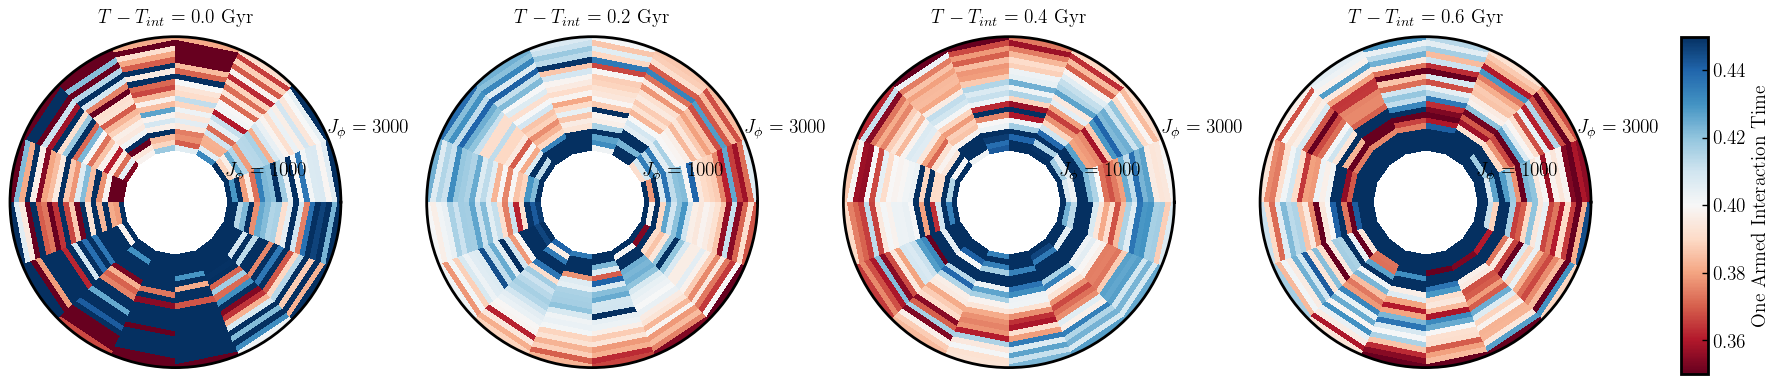

In [23]:
first_timestep = 3
fig, [ax1, ax2, ax3, ax4] = plt.subplots(1, 4, figsize=(18, 4.5), subplot_kw={'projection': 'polar'})

timestep=first_timestep+0
# pc_rc_amp = pc_rc[:n_channels] 
# pc_rc_amp = pc_rc_amp - np.mean(pc_rc_amp, axis=0)
# rad_mean_amp = np.mean(np.reshape(pc_rc_amp[:,timestep], T.shape, 'F'), axis=0)
# amp_vmax=0.5

im1 = ax1.pcolormesh(T, J, np.reshape(pc_rc[:,timestep], T.shape, 'F'), 
                          cmap='RdBu', rasterized=True,
                          vmin=0.35, vmax=0.45)
ax1.set_title(r'$T - T_{int} = 0.0$ Gyr', pad=10, fontsize=14)



timestep=first_timestep+20
# pc_rc_amp = pc_rc[:n_channels] 
# pc_rc_amp = pc_rc_amp - np.mean(pc_rc, axis=0)
# rad_mean_amp = np.mean(np.reshape(pc_rc[:,timestep], T.shape, 'F'), axis=0)
# amp_vmax=0.5

im2 = ax2.pcolormesh(T, J, np.reshape(pc_rc[:,timestep], T.shape, 'F'), 
                          cmap='RdBu', rasterized=True,
                          vmin=0.35, vmax=0.45)
ax2.set_title(r'$T - T_{int} = 0.2$ Gyr', pad=10, fontsize=14)



timestep=first_timestep+40

im3 = ax3.pcolormesh(T, J, np.reshape(pc_rc[:,timestep], T.shape, 'F'), 
                          cmap='RdBu', rasterized=True,
                          vmin=0.35, vmax=0.45)
ax3.set_title(r'$T - T_{int} = 0.4$ Gyr', pad=10, fontsize=14)


timestep=first_timestep+60

im5 = ax4.pcolormesh(T, J, np.reshape(pc_rc[:,timestep], T.shape, 'F'), 
                          cmap='RdBu', rasterized=True,
                          vmin=0.35, vmax=0.45)
ax4.set_title(r'$T - T_{int} = 0.6$ Gyr', pad=10, fontsize=14)

for ax in [ax1, ax2, ax3, ax4]:
    ax.set_yticks([np.min(jphi_c), np.max(jphi_c)], labels=[r'$J_\phi=1000$', r'$J_\phi=3000$'])
    ax.set_rmax(np.max(jphi_c))
    ax.tick_params(left = False, right = False , labelleft = True ,
                         labelbottom = False, bottom = False)
    ax.grid(visible=False)

            

fig.tight_layout()


fig.subplots_adjust(right=0.89)
cbar_ax = fig.add_axes([0.94, 0.1, 0.015, 0.75])
cbar = fig.colorbar(im3, cax=cbar_ax)
cbar.set_label('One Armed Interaction Time')
# plt.savefig(fig_dir + 'm1_amplitudes_paper.pdf')
plt.show()

In [138]:
mpl.style.use('/Users/Tavangar/.matplotlib/matplotlibrc')

In [210]:
np.where(np.median(np.reshape(pc_rc, (80, 16, 21), 'F'), axis=1) == np.max(np.median(np.reshape(pc_rc, (80, 16, 21), 'F'), axis=1)))

(array([75]), array([0]))

In [212]:
np.median(np.reshape(pc_rc, (80, 16, 21), 'F'), axis=1).shape

(80, 21)

<>:65: SyntaxWarning: invalid escape sequence '\p'

<>:65: SyntaxWarning: invalid escape sequence '\p'

/var/folders/f1/wqzqbly11d9__jf5mjckhwvm0000gq/T/ipykernel_26723/20496920.py:65: SyntaxWarning: invalid escape sequence '\p'
  ax4.plot(0.01*np.arange(40,120), np.median(np.reshape(pc_rc, (80, 16, 21), 'F'), axis=1)[:,i], label='$J_\phi={}$'.format(1000+100*i))



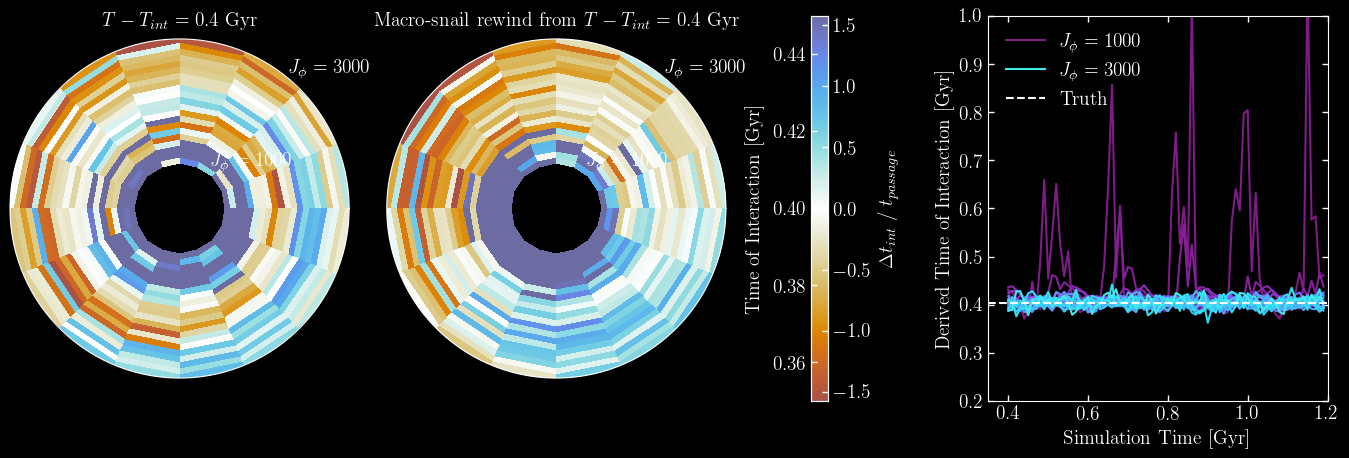

In [227]:
dipole_timestep = 0
future_timestep = dipole_timestep + 40 #timesteps

jbins=20

time_diff = times[1]-times[0]
ratio = 0.01

# mpl.style.use(['default','/Users/Tavangar/.matplotlib/matplotlibrc'])
mpl.style.use('dark_background')

fig = plt.figure(figsize=(17, 5))

# Define grid with space between columns 1–2 and 3
gs = mpl.gridspec.GridSpec(1, 6, width_ratios=[1, 1, 0.03, 0.05, 0.25, 1], wspace=0.2)

ax2 = fig.add_subplot(gs[0], projection='polar')  # First panel
ax3 = fig.add_subplot(gs[1], projection='polar')  # Second panel
extra_space = gs[2]
cbar_space = gs[3]
extra_space2 = gs[4]
ax4 = fig.add_subplot(gs[5])     

# im1 = ax1.pcolormesh(T, J, np.reshape(pc_rc[:,dipole_timestep], T.shape, 'F'), 
#                      cmap='RdBu', rasterized=True,
#                      vmin=0.35, vmax=0.45, shading='nearest')


time_elapsed = (future_timestep - dipole_timestep) * ratio
d_rot = (time_elapsed * omega_phi)

#now interpolate at each radius so that I can use the same grid as before
interp = scipy.interpolate.interp1d(tphi_c, pc_rc[:,future_timestep].reshape((jbins+1, 16)), axis=1, 
                                    fill_value="extrapolate")
all_interp = interp((T+d_rot)%(2*np.pi))
future_grid = np.diagonal(all_interp, axis1=0, axis2=2)

im2 = ax2.pcolormesh(T, J, np.reshape(pc_rc[:,future_timestep], T.shape, 'F'), 
                     cmap=cmr.prinsenvlag, rasterized=True,
                     vmin=0.35, vmax=0.45, shading='nearest')

#plot what that timestep looks like after subtracting background
im3a = ax3.pcolormesh(T, J, 1e3*(future_grid-0.4)/31.721, cmap=cmr.prinsenvlag, rasterized=True,
                vmin=-1.57, vmax=1.57, shading='nearest')
im3 = ax3.pcolormesh(T, J, future_grid, cmap=cmr.prinsenvlag, rasterized=True,
                vmin=0.35, vmax=0.45, shading='nearest')


ax1.set_title(r'$T_{int}$', pad=10, fontsize=14)
ax3.set_title(r'Macro-snail rewind from $T - T_{int} = 0.4$ Gyr', pad=10, fontsize=14)
ax2.set_title(r'$T - T_{int} = 0.4$ Gyr', pad=10, fontsize=14)


for ax in [ax1, ax2, ax3]:
    ax.set_yticks([np.min(jphi_c), np.max(jphi_c)], labels=[r'$J_\phi=1000$', r'$J_\phi=3000$'], fontsize=14, color='w')
    ax.set_rmax(np.max(jphi_c))
    ax.tick_params(left = False, right = False , labelleft = True ,
                         labelbottom = False, bottom = False)      
    ax.grid(visible=False)
    ax.set_rlabel_position(50)

ax4.set_prop_cycle(color=cmr.gem(np.linspace(0.3, 1, 21)))
for i in range(21):
    if (i==0) | (i==20):
        ax4.plot(0.01*np.arange(40,120), np.median(np.reshape(pc_rc, (80, 16, 21), 'F'), axis=1)[:,i], label='$J_\phi={}$'.format(1000+100*i))
    else:
        ax4.plot(0.01*np.arange(40,120), np.median(np.reshape(pc_rc, (80, 16, 21), 'F'), axis=1)[:,i])
# plt.plot(0.01*tbl_int_time[:,0], np.mean(tbl_int_time[:,1:250], axis=1), label='Inner average')
# ax4.plot([0.3,1.2], [0.3,1.2], label=r'$x=y$', ls='--', c='k')
ax4.axhline(0.403, ls='--', c='w', label='Truth')
ax4.legend(loc='upper left')
ax4.set_xlabel('Simulation Time [Gyr]', fontsize=14)
ax4.set_ylabel('Derived Time of Interaction [Gyr]', fontsize=14)
ax4.set_xlim(0.35,1.2) ; ax4.set_ylim(0.2,1)
# ax4.set_aspect('equal')

# fig.tight_layout()

from matplotlib.ticker import FixedLocator
# fig.subplots_adjust(right=0.88)
cbar_ax = fig.add_subplot(cbar_space)
cbar = fig.colorbar(im3, cax=cbar_ax)
cbar.set_label('Time of Interaction [Gyr]', labelpad=20)
cbar_ax.yaxis.tick_left()
cbar_ax.yaxis.label_position='left'

cbar_ax2 = cbar_ax.twinx()
cbar_ax2.yaxis.tick_right()
cbar_ax2.yaxis.label_position='right'
cbar_ax2.set_ylim(-0.05/0.031721,0.05/0.031721)
cbar_ax2.set_ylabel(r'$\Delta t_{int}$ / $t_{passage}$ ',size=14)
# cbar_ax2.set_yticks([-1.5,-1, -0.5,0,0.5,1,1.5])


plt.savefig(fig_dir + 'rewind_m1_time_of_int_dark_bkg.png')
plt.show()

#### With data

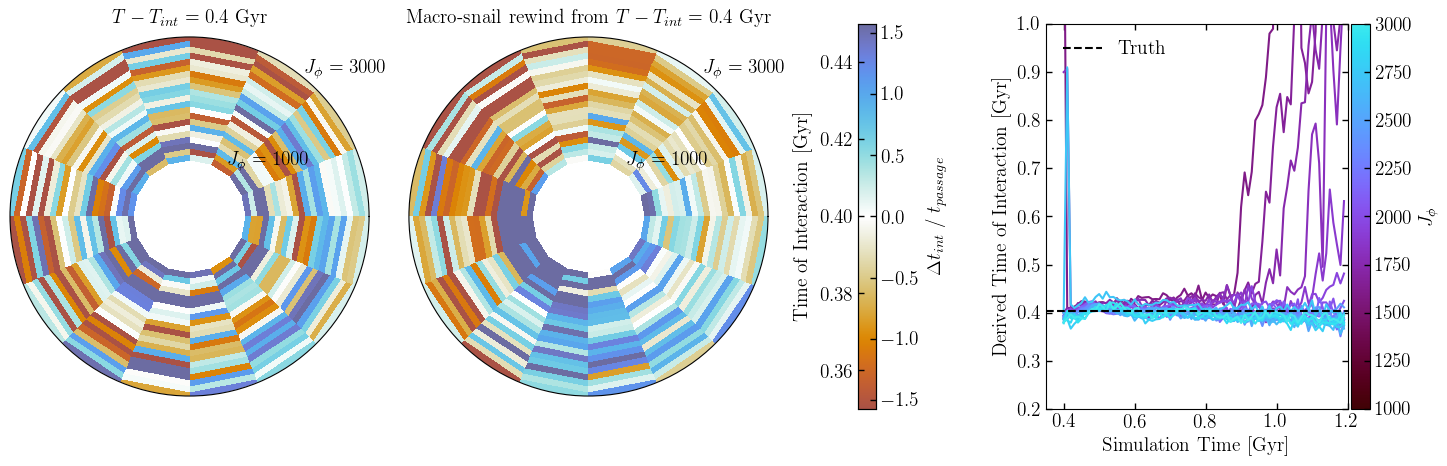

In [42]:
dipole_timestep = 0
future_timestep = dipole_timestep + 40 #timesteps

jbins=20

time_diff = times[1]-times[0]
ratio = 0.01

mpl.style.use(['default','/Users/Tavangar/.matplotlib/matplotlibrc'])
# mpl.style.use('dark_background')

fig = plt.figure(figsize=(18, 5))

# Define grid with space between columns 1–2 and 3
gs = mpl.gridspec.GridSpec(1, 6, width_ratios=[1, 1, 0.03, 0.05, 0.25, 1], wspace=0.2)

ax2 = fig.add_subplot(gs[0], projection='polar')  # First panel
ax3 = fig.add_subplot(gs[1], projection='polar')  # Second panel
extra_space = gs[2]
cbar_space = gs[3]
extra_space2 = gs[4]
ax4 = fig.add_subplot(gs[5])     

# im1 = ax1.pcolormesh(T, J, np.reshape(pc_rc[:,dipole_timestep], T.shape, 'F'), 
#                      cmap='RdBu', rasterized=True,
#                      vmin=0.35, vmax=0.45, shading='nearest')


time_elapsed = (future_timestep - dipole_timestep) * ratio
d_rot = (time_elapsed * omega_phi)

#now interpolate at each radius so that I can use the same grid as before
interp = scipy.interpolate.interp1d(tphi_c, tbl_int_time[future_timestep,1:].reshape((jbins+1, 16)), axis=1, 
                                    fill_value="extrapolate")
all_interp = interp((T+d_rot)%(2*np.pi))
future_grid = np.diagonal(all_interp, axis1=0, axis2=2)

im2 = ax2.pcolormesh(T, J, np.reshape(tbl_int_time[future_timestep,1:], T.shape, 'F'), 
                     cmap=cmr.prinsenvlag, rasterized=True,
                     vmin=0.35, vmax=0.45, shading='nearest')

#plot what that timestep looks like after subtracting background
im3a = ax3.pcolormesh(T, J, 1e3*(future_grid-0.4)/31.721, cmap=cmr.prinsenvlag, rasterized=True,
                vmin=-1.57, vmax=1.57, shading='nearest')
im3 = ax3.pcolormesh(T, J, future_grid, cmap=cmr.prinsenvlag, rasterized=True,
                vmin=0.35, vmax=0.45, shading='nearest')


ax1.set_title(r'$T_{int}$', pad=10, fontsize=14)
ax3.set_title(r'Macro-snail rewind from $T - T_{int} = 0.4$ Gyr', pad=10, fontsize=14)
ax2.set_title(r'$T - T_{int} = 0.4$ Gyr', pad=10, fontsize=14)


for ax in [ax2, ax3]:
    ax.set_yticks([np.min(jphi_c), np.max(jphi_c)], labels=[r'$J_\phi=1000$', r'$J_\phi=3000$'], fontsize=14, color='k')
    ax.set_rmax(np.max(jphi_c))
    ax.tick_params(left = False, right = False , labelleft = True ,
                         labelbottom = False, bottom = False)      
    ax.grid(visible=False)
    ax.set_rlabel_position(50)

from matplotlib.ticker import FixedLocator
# fig.subplots_adjust(right=0.88)
cbar_ax = fig.add_subplot(cbar_space)
cbar = fig.colorbar(im3, cax=cbar_ax)
cbar.set_label('Time of Interaction [Gyr]', labelpad=20)
cbar_ax.yaxis.tick_left()
cbar_ax.yaxis.label_position='left'

cbar_ax2 = cbar_ax.twinx()
cbar_ax2.yaxis.tick_right()
cbar_ax2.yaxis.label_position='right'
cbar_ax2.set_ylim(-0.05/0.031721,0.05/0.031721)
cbar_ax2.set_ylabel(r'$\Delta t_{int}$ / $t_{passage}$ ',size=14)

# Define the range of J_phi values
jphi_vals = 1000 + 100 * np.arange(21)

# Create color normalization and mappable for colorbar
norm = Normalize(vmin=jphi_vals.min(), vmax=jphi_vals.max())
cmap = cmr.gem
sm = ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])  # Required for colorbar

# Set color cycle
colors = cmap(np.linspace(0.3, 1, 21))
ax4.set_prop_cycle(color=colors)

# Plot each line
for i in range(21):
    yvals = np.median(np.reshape(tbl_int_time[:,1:], (80, 16, 21), 'F'), axis=1)[:,i]
    ax4.plot(0.01*np.arange(40,120), yvals)

# Plot truth line
ax4.axhline(0.403, ls='--', c='k', label='Truth')

# Add legend
ax4.legend(loc='upper left')

# Labels and limits
ax4.set_xlabel('Simulation Time [Gyr]', fontsize=14)
ax4.set_ylabel('Derived Time of Interaction [Gyr]', fontsize=14)
ax4.set_xlim(0.35,1.2)
ax4.set_ylim(0.2,1)

# Add colorbar
cbar = fig.colorbar(sm, ax=ax4, pad=0.01)
cbar.set_label(r'$J_\phi$')

plt.show()

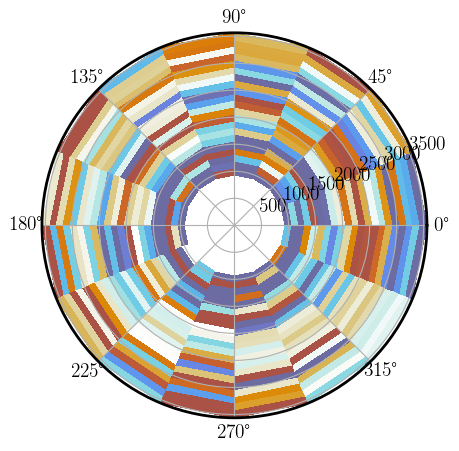

In [185]:
fig, ax = plt.subplots(1,1,figsize=(5, 5), subplot_kw={'projection': 'polar'})

ax.pcolormesh(T, J, np.reshape(der_int_time[50], T.shape, 'F'), 
                     cmap=cmr.prinsenvlag, rasterized=True,
                     vmin=0.35, vmax=0.45, shading='nearest')
plt.show()

**Plot different j_phi bins here too to make comparison to nbody simulation easier**

In [165]:
T.shape

(16, 21)

In [179]:
np.median(np.reshape(der_int_time, (80,16,21), 'F'), axis=1).max()

np.float64(2.17)

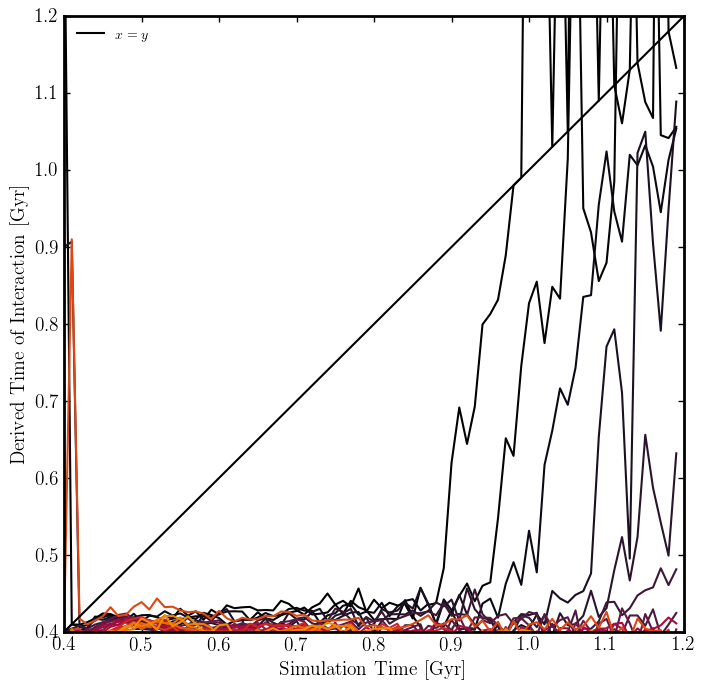

In [181]:
der_int_time = tbl_int_time[:,1:]

fig, ax = plt.subplots(1,1, figsize=(8,8))
ax.set_prop_cycle(color=cmr.ember(np.linspace(0, 1, 26)))

for i in range(21):
    ax.plot(0.01*np.arange(40,120), np.median(np.reshape(der_int_time, (80,16,21), 'F'), axis=1)[:,i])
ax.plot([0.4, 1.2], [0.4,1.2], label=r'$x=y$', c='k')
ax.legend(loc='upper left', fontsize=10, ncols=3)
ax.set_xlim(0.4,1.2)
ax.set_ylim(0.4,1.2)
ax.set_xlabel('Simulation Time [Gyr]')
ax.set_ylabel('Derived Time of Interaction [Gyr]')
plt.show()

In [ ]:
fig, ax = plt.subplots(1,1, figsize=(8,8))
ax.set_prop_cycle(color=cmr.ember(np.linspace(0, 1, 31)))

clean_dat = dat[(dat['pitch_phase_flag_m1'] == 0) & (dat['time_since_int_m1'] > 1e-4)]
grouped_clean_dat = dat.group_by(['timestep', 'jphi_cen'])
median_grouped = grouped_clean_dat.groups.aggregate(np.median)

for jphi in np.flip(np.unique(grouped_clean_dat['jphi_cen'])):
    to_plot = median_grouped[median_grouped['jphi_cen']==jphi]
    ax.plot(to_plot['timestep'] * 0.009778, to_plot['rewind_time_m1'], label=r'$J_\phi = $'+str(jphi))
plt.plot([2.4, 6], [2.4,6], label=r'$x=y$', c='k')
plt.legend(loc='upper left', fontsize=10, ncols=3)
plt.xlim(2.4,6)
plt.ylim(2.4,6)
plt.xlabel('Simulation Time [Gyr]')
plt.ylabel('Derived Time of Interaction [Gyr]')
plt.show()

Time of interaction based on $r_{peri}/v_{peri}$ is 31.7 Myr